Below is the third self-designed architecture: GNN + One-Class Clean Autoencoder Rejector.

The key idea is to treat the GNN as a candidate generator and the clean autoencoder as a precision filter. Your recent outcomes show that recall for bridging and stuck-at is already strong, but precision suffers because many clean nodes are accepted as faults. So this architecture trains a one-class denoising autoencoder only on clean nodes, especially hard clean nodes that the GNN tends to confuse as faults. During inference, a node is assigned to a fault class only if both the GNN score and clean-autoencoder anomaly score support the fault. This aligns with your papers formulation of four-class node-level fault detection using structural and relational circuit features.

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-

Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Number of classes: 4
Clean class index: 1
Fault class indices: [0, 2, 3]
Gate vocabulary: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Gate one-hot dimension: 7

Total netlists: 30
Train netlists: 24
Test netlists:  6
Validation netlists: 0  (paper-style protocol uses no validation split)

Train netlists (24):
-------------------
01. Priority.v
02. adder.v
03. arbiter.v
04. bar.v
05. c1355.v
06. c17.v
07. c1908.v
08. c2670.v
09. c499.v
10. c5315.v
11. c6288.v
12. c7552.v
13. c880.v
14. ctrl.v
15. div.v
16. i2c.v
17. int2float.v
18. log2.v
19. max.v
20. multiplier.v
21. router.v
22. sin.v
23. square.v
24. voter.v

Test netlists (6):
------------------
01. c3540.v
02. c432.v
03. cavlc.v
04. dec.v
05. memctrl.v
06. sqrt.v

Split sanity check:
-------------------
Train and Test overlap: []

No overlap found between train/test netlists.

Built graphs: train=24, test=6
Initial input dimension: 18

Test graph netlists and

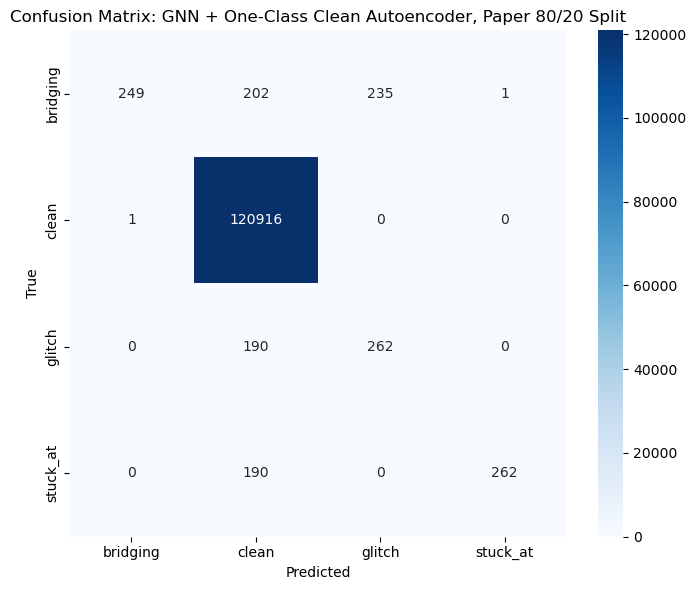


Test AE diagnostics:
      bridging: err_mean=9321290752.000000, err_95pct=9395441664.000000, anom_mean=1.0000, anom_95pct=1.0000
         clean: err_mean=3766.840088, err_95pct=35.792740, anom_mean=0.8057, anom_95pct=0.9997
        glitch: err_mean=9267399680.000000, err_95pct=9322899456.000000, anom_mean=1.0000, anom_95pct=1.0000
      stuck_at: err_mean=11204268032.000000, err_95pct=11240683520.000000, anom_mean=1.0000, anom_95pct=1.0000

Test final fault-score diagnostics:

bridging:
  threshold:                  0.9000
  true bridging mean score:     0.9319
  true bridging 5th percentile: 0.8250
  clean mean score:            0.1774
  clean 95th percentile:       0.2499
  clean 99th percentile:       0.2500

glitch:
  threshold:                  0.6600
  true glitch mean score:     0.9331
  true glitch 5th percentile: 0.6370
  clean mean score:            0.1774
  clean 95th percentile:       0.2499
  clean 99th percentile:       0.2500

stuck_at:
  threshold:                  0.

In [1]:
# ============================================================
# Paper-Protocol Self-Designed Architecture 3:
# GNN + One-Class Clean Autoencoder Rejector
# for Circuit Fault Detection from Enhanced CSVs
#
# Goal:
#   Improve precision for bridging and stuck_at by rejecting clean false positives.
#
# Stage 1:
#   Long-Short-GNN candidate generator
#     - short-view edge-aware GAT
#     - long-view multi-scale APPNP
#     - high-recall node classifier
#
# Stage 2:
#   One-class clean denoising autoencoder
#     - trained only on clean TRAIN nodes
#     - includes hard clean nodes that GNN scores as fault-like
#     - learns clean manifold in GNN/meta-feature space
#
# Paper-protocol refinement:
#   - 80/20 split by netlist_file
#   - no validation netlists
#   - held-out test netlists printed explicitly
#   - Stage-1 GNN trained for fixed 100 epochs
#   - paper-close GNN settings: HID=64, DROPOUT=0.4, LR=7e-4
#   - train-only normalization
#   - clean AE trained only from train netlists
#   - thresholds calibrated only from train netlists
#   - final evaluation only on nodes from held-out test netlists
#
# Inputs:
#   nodes_enhanced.csv
#   edges_enhanced.csv
#
# This cell defines:
#   nodes_df, edges_df, train_nets, test_nets
# and creates empty val_nets/val_graphs placeholders for compatibility.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import re
import math
import random
import warnings
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader as TorchDataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import (
        GATConv,
        APPNP,
        global_mean_pool,
        global_max_pool,
    )
except Exception as e:
    raise RuntimeError(
        "PyTorch Geometric is required. Install a PyG version compatible "
        "with your PyTorch/CUDA setup before running this notebook."
    ) from e


# -------------------------
# Reproducibility
# -------------------------
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


# -------------------------
# Files
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"


# -------------------------
# Paper-style split settings
# -------------------------
TEST_RATIO = 0.20

# Paper-code behavior generally preferred clean topology if available.
# Set EDGE_MODE="union" only if you intentionally want fault-aware topology.
EDGE_MODE = "clean"       # choices: "clean", "union"


# -------------------------
# Stage 1 GNN hyperparameters
# -------------------------
EPOCHS = 100

LR = 7e-4
WEIGHT_DECAY = 5e-4

HID = 64
DROPOUT = 0.4

SHORT_GAT_LAYERS = 2
SHORT_GAT_HEADS = 4

LONG_PROP_STEPS_LIST = [3, 10]
LONG_ALPHA = 0.10

BATCH_SIZE = 1

MAX_FAULT_NODES_PER_CLASS_PER_GRAPH = 512
CLEAN_TO_FAULT_RATIO_GNN = 1.0
HARD_CLEAN_FRACTION_GNN = 0.50

# Mild margin losses help reduce clean -> fault false positives.
CLEAN_MARGIN_WEIGHT = 0.12
FAULT_MARGIN_WEIGHT = 0.06
LOGIT_MARGIN = 1.0

# Model selection:
# "test_loss" mimics the original paper scripts, where the held-out split
# was monitored during training.
# "train_loss" avoids test-based checkpoint selection.
MODEL_SELECTION_CRITERION = "test_loss"     # choices: "test_loss", "train_loss"


# -------------------------
# Stage 2 clean autoencoder hyperparameters
# -------------------------
AE_EPOCHS = 100
AE_LR = 1e-3
AE_WEIGHT_DECAY = 1e-5

AE_BATCH_SIZE = 1024
AE_LATENT_DIM = 48
AE_HIDDEN_DIM = 256
AE_DROPOUT = 0.10
AE_NOISE_STD = 0.03

# Maximum clean nodes used to train the one-class AE.
AE_MAX_CLEAN_TRAIN = 160000

# Fraction of AE clean nodes selected from hard clean false-positive candidates.
AE_HARD_CLEAN_FRACTION = 0.65


# -------------------------
# Train-only threshold calibration
# -------------------------
THRESHOLD_GRID = np.linspace(0.05, 0.995, 190)

RECALL_FLOOR_BY_CLASS_NAME = {
    "bridging": 0.82,
    "glitch": 0.88,
    "stuck_at": 0.94,
}

BETA_BY_CLASS_NAME = {
    "bridging": 0.35,
    "glitch": 0.75,
    "stuck_at": 0.50,
}

POST_THRESHOLD_OFFSET_BY_CLASS_NAME = {
    "bridging": 0.04,
    "glitch": 0.00,
    "stuck_at": 0.02,
}


# -------------------------
# Optional prior-aware cap
# -------------------------
USE_PRIOR_AWARE_CAP = True

PRIOR_CAP_MULTIPLIER_BY_CLASS_NAME = {
    "bridging": 1.5,
    "glitch": 2.5,
    "stuck_at": 2.5,
}

MIN_CAP_PER_GRAPH_BY_CLASS_NAME = {
    "bridging": 10,
    "glitch": 10,
    "stuck_at": 10,
}


PRINT_EVERY = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ============================================================
# 2. Load enhanced CSV files
# ============================================================

nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

required_node_cols = [
    "netlist_file", "fault_type", "node_id", "gate_type", "label",
    "in_degree", "out_degree", "total_degree", "path_depth",
    "CC0_exact", "CC1_exact", "CO_exact", "dist_to_PO",
    "fanout", "fanout_norm", "gate_delay",
]

required_edge_cols = [
    "netlist_file", "fault_type", "src_node", "dst_node",
]

for c in required_node_cols:
    if c not in nodes_df.columns:
        raise ValueError(f"Missing required node column: {c}")

for c in required_edge_cols:
    if c not in edges_df.columns:
        raise ValueError(f"Missing required edge column: {c}")

if "fan_out" not in edges_df.columns:
    if "fanout" in edges_df.columns:
        edges_df = edges_df.rename(columns={"fanout": "fan_out"})
    else:
        warnings.warn("edges_enhanced.csv has no fan_out column. Using fan_out=1.0.")
        edges_df["fan_out"] = 1.0


for c in ["netlist_file", "fault_type", "node_id", "gate_type"]:
    nodes_df[c] = nodes_df[c].astype(str)

for c in ["netlist_file", "fault_type", "src_node", "dst_node"]:
    edges_df[c] = edges_df[c].astype(str)


base_num_cols = [
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
]

for c in base_num_cols:
    nodes_df[c] = (
        pd.to_numeric(nodes_df[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )

nodes_df["label"] = (
    pd.to_numeric(nodes_df["label"], errors="coerce")
    .fillna(0)
    .astype(int)
)

edges_df["fan_out"] = (
    pd.to_numeric(edges_df["fan_out"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .astype(np.float32)
)


# ============================================================
# 3. Encode labels and gate types
# ============================================================

le = LabelEncoder()
nodes_df["fault_cls"] = le.fit_transform(nodes_df["fault_type"])

class_names = list(le.classes_)
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

if "clean" not in class_to_idx:
    raise ValueError("Expected a 'clean' class in fault_type.")

clean_idx = class_to_idx["clean"]

fault_class_indices = [i for i in range(num_classes) if i != clean_idx]
fault_idx_to_local = {cls_idx: j for j, cls_idx in enumerate(fault_class_indices)}
local_to_fault_idx = {j: cls_idx for cls_idx, j in fault_idx_to_local.items()}

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Clean class index:", clean_idx)
print("Fault class indices:", fault_class_indices)


def canonical_gate_type(gate_type: str) -> str:
    s = str(gate_type).strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)

    if s in {"sa0", "sa1", "bridge", "glitch"}:
        return "other"
    if s.startswith("sa0") or s.startswith("sa1"):
        return "other"
    if s.startswith("br_") or s.startswith("bridge"):
        return "other"
    if s.startswith("gl_") or s.startswith("glitch"):
        return "other"

    if s.startswith("nand"):
        return "nand"
    if s.startswith("and"):
        return "and"
    if s.startswith("nor"):
        return "nor"
    if s.startswith("or"):
        return "or"
    if s.startswith("xnor"):
        return "xnor"
    if s.startswith("xor"):
        return "xor"
    if s.startswith("inv") or s.startswith("not"):
        return "not"
    if s.startswith("buf") or s.startswith("buff"):
        return "buf"
    if s in {"pi", "po"}:
        return s

    return "other"


nodes_df["gate_canon"] = nodes_df["gate_type"].map(canonical_gate_type)

gate_vocab = sorted(nodes_df["gate_canon"].unique().tolist())
if "other" not in gate_vocab:
    gate_vocab.append("other")
gate_vocab = sorted(gate_vocab)

g2i = {g: i for i, g in enumerate(gate_vocab)}
GATE_DIM = len(gate_vocab)

print("Gate vocabulary:", gate_vocab)
print("Gate one-hot dimension:", GATE_DIM)


# ============================================================
# 4. Paper-style 80/20 train/test split by netlist
# ============================================================

# Use drop_duplicates order, matching the paper-code scripts.
netlists = nodes_df["netlist_file"].drop_duplicates().values

if len(netlists) < 4:
    raise ValueError(
        f"Only {len(netlists)} netlists found. Need at least 4 for train/test."
    )

train_nets, test_nets = train_test_split(
    netlists,
    test_size=TEST_RATIO,
    random_state=SEED,
    shuffle=True,
)

# Compatibility placeholders for older split-printing cells.
val_nets = np.array([], dtype=object)
val_graphs = []

print(f"\nTotal netlists: {len(netlists)}")
print(f"Train netlists: {len(train_nets)}")
print(f"Test netlists:  {len(test_nets)}")
print("Validation netlists: 0  (paper-style protocol uses no validation split)")


def print_split_netlists(split_name, netlist_array):
    netlist_list = sorted([str(x) for x in netlist_array])

    print(f"\n{split_name} netlists ({len(netlist_list)}):")
    print("-" * (len(split_name) + 14))

    for i, nf in enumerate(netlist_list, start=1):
        print(f"{i:02d}. {nf}")


print_split_netlists("Train", train_nets)
print_split_netlists("Test", test_nets)

train_set = set(map(str, train_nets))
test_set = set(map(str, test_nets))

print("\nSplit sanity check:")
print("-------------------")
print("Train and Test overlap:", sorted(train_set & test_set))

assert len(train_set & test_set) == 0, "Train and test netlists overlap!"

print("\nNo overlap found between train/test netlists.")


# ============================================================
# 5. Build one joint graph per netlist
# ============================================================

def select_edges_for_netlist(nf: str) -> pd.DataFrame:
    all_e = edges_df[edges_df["netlist_file"] == nf]

    if EDGE_MODE == "clean":
        clean_e = all_e[all_e["fault_type"] == "clean"]
        use_e = clean_e if not clean_e.empty else all_e
    elif EDGE_MODE == "union":
        use_e = all_e
    else:
        raise ValueError("EDGE_MODE must be 'clean' or 'union'.")

    if use_e.empty:
        return use_e

    return (
        use_e.groupby(["src_node", "dst_node"], as_index=False)["fan_out"]
        .mean()
    )


def build_joint_graphs(nets: np.ndarray) -> List[Data]:
    graphs = []

    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf].copy()

        if nd_sub.empty:
            continue

        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid: i for i, nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_rows = (
            nd_sub[nd_sub["fault_type"] == "clean"]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        fault_label_rows = (
            nd_sub[(nd_sub["fault_type"] != "clean") & (nd_sub["label"] == 1)]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        first_rows = (
            nd_sub.drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        clean_set = set(clean_rows.index)
        fault_label_set = set(fault_label_rows.index)

        x_gate = np.zeros((N, GATE_DIM), dtype=np.float32)
        x_num = np.zeros((N, len(base_num_cols)), dtype=np.float32)

        for i, nid in enumerate(node_ids):
            if nid in clean_set:
                row = clean_rows.loc[nid]
            elif nid in fault_label_set:
                row = fault_label_rows.loc[nid]
            else:
                row = first_rows.loc[nid]

            gate = canonical_gate_type(row["gate_type"])
            gate_idx = g2i.get(gate, g2i["other"])
            x_gate[i, gate_idx] = 1.0

            x_num[i, :] = row[base_num_cols].astype(np.float32).values

        x = np.concatenate([x_gate, x_num], axis=1)

        y = np.full(N, fill_value=clean_idx, dtype=np.int64)

        faulty_rows = nd_sub[
            (nd_sub["fault_type"] != "clean") &
            (nd_sub["label"] == 1)
        ]

        for _, r in faulty_rows.iterrows():
            nid = r["node_id"]
            ft = r["fault_type"]

            if nid in id2idx and ft in class_to_idx:
                y[id2idx[nid]] = class_to_idx[ft]

        e_use = select_edges_for_netlist(nf)

        src_list, dst_list, edge_attrs = [], [], []

        if not e_use.empty:
            max_fanout = float(max(e_use["fan_out"].max(), 1.0))

            for _, erow in e_use.iterrows():
                s = erow["src_node"]
                d = erow["dst_node"]

                if s in id2idx and d in id2idx:
                    fan = max(float(erow["fan_out"]), 0.0)

                    src_list.append(id2idx[s])
                    dst_list.append(id2idx[d])

                    edge_attrs.append([
                        math.log1p(fan),
                        fan / max_fanout,
                        1.0,
                        0.0,
                    ])

        if len(src_list) > 0:
            edge_index_directed = torch.tensor([src_list, dst_list], dtype=torch.long)
            edge_attr_directed = torch.tensor(edge_attrs, dtype=torch.float32)
        else:
            edge_index_directed = torch.empty((2, 0), dtype=torch.long)
            edge_attr_directed = torch.empty((0, 4), dtype=torch.float32)

        data = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=edge_index_directed,
            edge_attr=edge_attr_directed,
            y=torch.tensor(y, dtype=torch.long),
        )

        data.edge_index_directed = edge_index_directed.clone()
        data.edge_attr_directed = edge_attr_directed.clone()
        data.netlist_file = nf

        graphs.append(data)

    return graphs


train_graphs = build_joint_graphs(train_nets)
test_graphs = build_joint_graphs(test_nets)

print(f"\nBuilt graphs: train={len(train_graphs)}, test={len(test_graphs)}")
print("Initial input dimension:", train_graphs[0].x.size(1))

print("\nTest graph netlists and node counts:")
print("------------------------------------")
for i, g in enumerate(test_graphs, start=1):
    print(f"{i:02d}. {g.netlist_file} | nodes={g.num_nodes}")

test_graph_names = set(str(g.netlist_file) for g in test_graphs)
test_net_names = set(map(str, test_nets))

assert test_graph_names <= test_net_names, "Some test graphs are not from test_nets."

print("\nAll test graphs were built only from test_nets.")


# ============================================================
# 6. Append relational features
# ============================================================

NUM_START = GATE_DIM
base_idx = {c: NUM_START + i for i, c in enumerate(base_num_cols)}

idx_CC0 = base_idx["CC0_exact"]
idx_CC1 = base_idx["CC1_exact"]
idx_CO = base_idx["CO_exact"]
idx_path = base_idx["path_depth"]
idx_distPO = base_idx["dist_to_PO"]


def build_adj_lists(edge_index: torch.Tensor, N: int):
    out_adj = [[] for _ in range(N)]
    in_adj = [[] for _ in range(N)]

    if edge_index.numel() == 0:
        return in_adj, out_adj

    src = edge_index[0].cpu().numpy().tolist()
    dst = edge_index[1].cpu().numpy().tolist()

    for s, d in zip(src, dst):
        out_adj[s].append(d)
        in_adj[d].append(s)

    return in_adj, out_adj


def neighbor_mean(arr: np.ndarray, adj):
    out = np.zeros(len(adj), dtype=np.float32)

    for u, neigh in enumerate(adj):
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])

    return out


def k_hop_unique_counts(adj, K: int = 3):
    N = len(adj)
    counts = np.zeros(N, dtype=np.float32)

    for u in range(N):
        seen = set()
        frontier = [u]

        for _ in range(K):
            nxt = []

            for v in frontier:
                for w in adj[v]:
                    if w != u and w not in seen:
                        seen.add(w)
                        nxt.append(w)

            frontier = nxt

            if not frontier:
                break

        counts[u] = float(len(seen))

    return counts


def count_reachable_targets(u: int, targets: set, adj, K: int = 3):
    seen = set()
    frontier = [u]

    for _ in range(K):
        nxt = []

        for v in frontier:
            for w in adj[v]:
                if w not in seen:
                    seen.add(w)
                    nxt.append(w)

        frontier = nxt

        if not frontier:
            break

    return float(sum(1 for w in seen if w in targets))


def append_relational_features(data: Data) -> Data:
    x = data.x.clone().float()
    N = x.size(0)

    edge_index_rel = data.edge_index_directed

    in_adj, out_adj = build_adj_lists(edge_index_rel, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co = x[:, idx_CO].cpu().numpy()

    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean = neighbor_mean(co, in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean = neighbor_mean(co, out_adj)

    cc0_in_delta = cc0 - cc0_in_mean
    cc1_in_delta = cc1 - cc1_in_mean
    co_in_delta = co - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta = co - co_out_mean

    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.float32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.float32)

    in_k2 = k_hop_unique_counts(in_adj, K=2)
    out_k2 = k_hop_unique_counts(out_adj, K=2)

    in_k3 = k_hop_unique_counts(in_adj, K=3)
    out_k3 = k_hop_unique_counts(out_adj, K=3)

    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()

    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    pi_anc3 = np.zeros(N, dtype=np.float32)
    po_des3 = np.zeros(N, dtype=np.float32)

    for u in range(N):
        pi_anc3[u] = count_reachable_targets(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reachable_targets(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean, cc1_in_mean, co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta, cc1_out_delta, co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3,
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)

    return data


for graph_list in [train_graphs, test_graphs]:
    for i in range(len(graph_list)):
        graph_list[i] = append_relational_features(graph_list[i])

print("Input dimension after relational features:", train_graphs[0].x.size(1))


# ============================================================
# 7. Add reverse edges
# ============================================================

def add_reverse_edges(graphs: List[Data]) -> List[Data]:
    for g in graphs:
        if g.edge_index_directed.numel() == 0:
            g.edge_index = torch.empty((2, 0), dtype=torch.long)
            g.edge_attr = torch.empty((0, 4), dtype=torch.float32)
            continue

        ei = g.edge_index_directed
        ea = g.edge_attr_directed.float()

        rev_ei = ei.flip(0)

        rev_ea = ea.clone()
        rev_ea[:, 2] = 0.0
        rev_ea[:, 3] = 1.0

        g.edge_index = torch.cat([ei, rev_ei], dim=1)
        g.edge_attr = torch.cat([ea, rev_ea], dim=0)

    return graphs


train_graphs = add_reverse_edges(train_graphs)
test_graphs = add_reverse_edges(test_graphs)


# ============================================================
# 8. Normalize node and edge features using train split only
# ============================================================

def fit_node_normalizer(graphs: List[Data]):
    X = torch.cat([g.x[:, NUM_START:] for g in graphs], dim=0).cpu().numpy()
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    mu = X.mean(axis=0).astype(np.float32)
    sigma = (X.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_node_normalizer(graphs: List[Data], mu: np.ndarray, sigma: np.ndarray):
    for g in graphs:
        X = g.x[:, NUM_START:].cpu().numpy()
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X = (X - mu) / sigma
        g.x[:, NUM_START:] = torch.from_numpy(X).float()

    return graphs


node_mu, node_sigma = fit_node_normalizer(train_graphs)

train_graphs = apply_node_normalizer(train_graphs, node_mu, node_sigma)
test_graphs = apply_node_normalizer(test_graphs, node_mu, node_sigma)


EDGE_NUM_DIMS = 2
EDGE_DIM = train_graphs[0].edge_attr.size(1) if train_graphs[0].edge_attr.numel() > 0 else 4


def fit_edge_normalizer(graphs: List[Data]):
    arrs = []

    for g in graphs:
        if g.edge_attr.numel() > 0:
            arrs.append(g.edge_attr[:, :EDGE_NUM_DIMS])

    if not arrs:
        mu = np.zeros(EDGE_NUM_DIMS, dtype=np.float32)
        sigma = np.ones(EDGE_NUM_DIMS, dtype=np.float32)
        return mu, sigma

    E = torch.cat(arrs, dim=0).cpu().numpy()
    E = np.nan_to_num(E, nan=0.0, posinf=0.0, neginf=0.0)

    mu = E.mean(axis=0).astype(np.float32)
    sigma = (E.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_edge_normalizer(graphs: List[Data], mu: np.ndarray, sigma: np.ndarray):
    for g in graphs:
        if g.edge_attr.numel() == 0:
            continue

        E = g.edge_attr.cpu().numpy()
        E[:, :EDGE_NUM_DIMS] = (E[:, :EDGE_NUM_DIMS] - mu) / sigma
        g.edge_attr = torch.from_numpy(E).float()

    return graphs


edge_mu, edge_sigma = fit_edge_normalizer(train_graphs)

train_graphs = apply_edge_normalizer(train_graphs, edge_mu, edge_sigma)
test_graphs = apply_edge_normalizer(test_graphs, edge_mu, edge_sigma)

print("Final node input dimension:", train_graphs[0].x.size(1))
print("Edge feature dimension:", EDGE_DIM)


# ============================================================
# 9. Class distributions and paper-style class weights
# ============================================================

def labels_from_graphs(graphs: List[Data]) -> np.ndarray:
    return np.concatenate([g.y.cpu().numpy() for g in graphs], axis=0)


train_labels_all = labels_from_graphs(train_graphs)
test_labels_all = labels_from_graphs(test_graphs)


def print_final_counts(split_name: str, labels: np.ndarray):
    counts = np.bincount(labels, minlength=num_classes)
    total = int(counts.sum())

    print(f"\n{split_name} final joint-graph class counts:")
    for i, cname in enumerate(class_names):
        pct = 100.0 * counts[i] / max(1, total)
        print(f"  {cname:>12s}: {int(counts[i]):>10d}  ({pct:6.3f}%)")


print_final_counts("Train", train_labels_all)
print_final_counts("Test", test_labels_all)


# Paper-style inverse-frequency weights.
train_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)
safe_train_counts = np.maximum(train_counts, 1.0)

weights_np = safe_train_counts.max() / (safe_train_counts + 1e-6)
weights_np = weights_np / weights_np.sum() * num_classes

class_weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)

train_priors = train_counts / max(train_counts.sum(), 1.0)

print("\nClass weights:", class_weights.detach().cpu().numpy())

print("\nTrain priors:")
for i, cname in enumerate(class_names):
    print(f"  {cname:>12s}: {train_priors[i]:.6f}")


# ============================================================
# 10. Stage 1 Long-Short-GNN candidate generator
# ============================================================

class ShortViewEdgeGAT(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        edge_dim: int,
        num_layers: int = 2,
        heads: int = 4,
        dropout: float = 0.4,
    ):
        super().__init__()

        if hidden_dim % heads != 0:
            raise ValueError("hidden_dim must be divisible by heads.")

        self.dropout_p = float(dropout)

        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_norm = nn.LayerNorm(hidden_dim)

        self.gat_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.layer_uses_edge_attr = []

        out_per_head = hidden_dim // heads

        for layer_idx in range(num_layers):
            try:
                conv = GATConv(
                    in_channels=hidden_dim,
                    out_channels=out_per_head,
                    heads=heads,
                    concat=True,
                    dropout=dropout,
                    add_self_loops=True,
                    edge_dim=edge_dim,
                )
                use_edge_attr = True
            except Exception as e:
                warnings.warn(
                    f"Edge-aware GATConv failed at short-view layer {layer_idx}; "
                    f"falling back to ordinary GATConv. Error: {repr(e)}"
                )
                conv = GATConv(
                    in_channels=hidden_dim,
                    out_channels=out_per_head,
                    heads=heads,
                    concat=True,
                    dropout=dropout,
                    add_self_loops=True,
                )
                use_edge_attr = False

            self.gat_layers.append(conv)
            self.norms.append(nn.LayerNorm(hidden_dim))
            self.layer_uses_edge_attr.append(use_edge_attr)

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = getattr(data, "edge_attr", None)

        h = self.input_proj(x)
        h = self.input_norm(h)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout_p, training=self.training)

        for conv, norm, use_edge_attr in zip(
            self.gat_layers,
            self.norms,
            self.layer_uses_edge_attr,
        ):
            if use_edge_attr and edge_attr is not None:
                h_msg = conv(h, edge_index, edge_attr=edge_attr)
            else:
                h_msg = conv(h, edge_index)

            h = norm(h + F.dropout(h_msg, p=self.dropout_p, training=self.training))
            h = F.elu(h)

        return h


class MultiScaleLongViewDiffusion(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        prop_steps_list: List[int],
        alpha: float = 0.10,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.dropout_p = float(dropout)

        self.input_mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.input_norm = nn.LayerNorm(hidden_dim)

        self.propagations = nn.ModuleList([
            APPNP(
                K=int(k),
                alpha=alpha,
                dropout=dropout,
            )
            for k in prop_steps_list
        ])

        self.multi_scale_proj = nn.Sequential(
            nn.Linear(hidden_dim * (1 + len(prop_steps_list)), hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.multi_scale_norm = nn.LayerNorm(hidden_dim)

        self.graph_context_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.context_fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.context_norm = nn.LayerNorm(hidden_dim)

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index

        h0 = self.input_mlp(x)
        h0 = self.input_norm(h0)
        h0 = F.elu(h0)

        h_scales = [h0]

        if edge_index.numel() == 0:
            for _ in self.propagations:
                h_scales.append(h0)
        else:
            for prop in self.propagations:
                h_prop = prop(h0, edge_index)
                h_scales.append(h_prop)

        h_cat = torch.cat(h_scales, dim=-1)

        h = self.multi_scale_proj(h_cat)
        h = self.multi_scale_norm(h0 + F.dropout(h, p=self.dropout_p, training=self.training))
        h = F.elu(h)

        if hasattr(data, "batch") and data.batch is not None:
            batch = data.batch
        else:
            batch = torch.zeros(
                h.size(0),
                dtype=torch.long,
                device=h.device,
            )

        h_mean = global_mean_pool(h, batch)
        h_max = global_max_pool(h, batch)

        h_graph = self.graph_context_proj(torch.cat([h_mean, h_max], dim=-1))
        h_graph_for_node = h_graph[batch]

        h_update = self.context_fusion(torch.cat([h, h_graph_for_node], dim=-1))
        h = self.context_norm(h + h_update)
        h = F.elu(h)

        return h


class LongShortFusion(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float = 0.4):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
        )

        self.refine = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, h_short: torch.Tensor, h_long: torch.Tensor):
        fusion_input = torch.cat(
            [
                h_short,
                h_long,
                torch.abs(h_short - h_long),
                h_short * h_long,
            ],
            dim=-1,
        )

        gate = self.gate(fusion_input)

        h = gate * h_short + (1.0 - gate) * h_long

        h_refined = self.refine(h)
        h = self.norm(h + h_refined)
        h = F.elu(h)

        return h, gate


class CandidateGNN(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        edge_dim: int,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.short_view = ShortViewEdgeGAT(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            edge_dim=edge_dim,
            num_layers=SHORT_GAT_LAYERS,
            heads=SHORT_GAT_HEADS,
            dropout=dropout,
        )

        self.long_view = MultiScaleLongViewDiffusion(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            prop_steps_list=LONG_PROP_STEPS_LIST,
            alpha=LONG_ALPHA,
            dropout=dropout,
        )

        self.fusion = LongShortFusion(
            hidden_dim=hidden_dim,
            dropout=dropout,
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, data: Data):
        h_short = self.short_view(data)
        h_long = self.long_view(data)

        h, gate = self.fusion(h_short, h_long)

        logits = self.classifier(h)

        return {
            "logits": logits,
            "embedding": h,
            "fusion_gate": gate,
        }


in_dim = train_graphs[0].x.size(1)

model = CandidateGNN(
    in_dim=in_dim,
    hidden_dim=HID,
    out_dim=num_classes,
    edge_dim=EDGE_DIM,
    dropout=DROPOUT,
).to(DEVICE)

print("\nStage-1 GNN model:")
print(model)
print("\nShort-view GAT uses edge attributes:", model.short_view.layer_uses_edge_attr)


# ============================================================
# 11. Train Stage-1 GNN for fixed 100 epochs
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

rng = np.random.default_rng(SEED)


def sample_gnn_training_idx(
    y: torch.Tensor,
    logits: torch.Tensor = None,
    max_fault_per_class: int = 512,
    clean_to_fault_ratio: float = 1.0,
    hard_clean_fraction: float = 0.50,
):
    y_np = y.detach().cpu().numpy()

    selected = []
    total_fault_selected = 0

    for c in range(num_classes):
        if c == clean_idx:
            continue

        c_idx = np.flatnonzero(y_np == c)

        if len(c_idx) == 0:
            continue

        k = min(len(c_idx), max_fault_per_class)
        chosen = rng.choice(c_idx, size=k, replace=False)

        selected.append(chosen)
        total_fault_selected += k

    clean_candidates = np.flatnonzero(y_np == clean_idx)

    if total_fault_selected > 0 and len(clean_candidates) > 0:
        k_clean_total = min(
            len(clean_candidates),
            int(math.ceil(clean_to_fault_ratio * total_fault_selected)),
        )

        k_hard = int(math.floor(hard_clean_fraction * k_clean_total))
        k_random = k_clean_total - k_hard

        hard_clean = np.array([], dtype=np.int64)

        if logits is not None and k_hard > 0:
            with torch.no_grad():
                probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
                max_fault_prob = probs[clean_candidates][:, fault_class_indices].max(axis=1)

            order = np.argsort(-max_fault_prob)
            hard_clean = clean_candidates[order[:min(k_hard, len(clean_candidates))]]

        if k_random > 0:
            if len(hard_clean) > 0:
                remaining_clean = np.setdiff1d(clean_candidates, hard_clean, assume_unique=False)
            else:
                remaining_clean = clean_candidates

            if len(remaining_clean) > 0:
                random_clean = rng.choice(
                    remaining_clean,
                    size=min(k_random, len(remaining_clean)),
                    replace=False,
                )
            else:
                random_clean = np.array([], dtype=np.int64)
        else:
            random_clean = np.array([], dtype=np.int64)

        clean_selected = np.unique(np.concatenate([hard_clean, random_clean]))

        if len(clean_selected) > 0:
            selected.append(clean_selected)

    if not selected:
        all_idx = np.arange(len(y_np))
        k = min(len(all_idx), 512)
        chosen = rng.choice(all_idx, size=k, replace=False)
        selected.append(chosen)

    selected = np.unique(np.concatenate(selected))

    return torch.tensor(selected, dtype=torch.long, device=DEVICE)


def margin_losses(logits: torch.Tensor, y: torch.Tensor, idx: torch.Tensor):
    y_sel = y[idx]
    logits_sel = logits[idx]

    clean_logits = logits_sel[:, clean_idx]
    fault_logits = logits_sel[:, fault_class_indices]

    clean_mask = y_sel == clean_idx
    fault_mask = y_sel != clean_idx

    if clean_mask.any():
        clean_lse_fault = torch.logsumexp(fault_logits[clean_mask], dim=1)
        clean_margin_loss = F.softplus(
            clean_lse_fault - clean_logits[clean_mask] + LOGIT_MARGIN
        ).mean()
    else:
        clean_margin_loss = torch.zeros((), dtype=logits.dtype, device=logits.device)

    if fault_mask.any():
        y_fault = y_sel[fault_mask]
        true_fault_logits = logits_sel[fault_mask, y_fault]
        clean_for_fault = clean_logits[fault_mask]
        fault_margin_loss = F.softplus(
            clean_for_fault - true_fault_logits + LOGIT_MARGIN
        ).mean()
    else:
        fault_margin_loss = torch.zeros((), dtype=logits.dtype, device=logits.device)

    return clean_margin_loss, fault_margin_loss


def train_gnn_one_epoch(graphs: List[Data]):
    model.train()

    loader = DataLoader(
        graphs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    total_loss = 0.0
    total_seen = 0
    total_correct = 0

    for data in loader:
        data = data.to(DEVICE)

        outputs = model(data)
        logits = outputs["logits"]

        idx = sample_gnn_training_idx(
            data.y,
            logits=logits,
            max_fault_per_class=MAX_FAULT_NODES_PER_CLASS_PER_GRAPH,
            clean_to_fault_ratio=CLEAN_TO_FAULT_RATIO_GNN,
            hard_clean_fraction=HARD_CLEAN_FRACTION_GNN,
        )

        ce_loss = F.cross_entropy(
            logits[idx],
            data.y[idx],
            weight=class_weights,
            reduction="mean",
        )

        clean_margin_loss, fault_margin_loss = margin_losses(logits, data.y, idx)

        loss = (
            ce_loss +
            CLEAN_MARGIN_WEIGHT * clean_margin_loss +
            FAULT_MARGIN_WEIGHT * fault_margin_loss
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        with torch.no_grad():
            pred = logits[idx].argmax(dim=1)
            total_correct += int((pred == data.y[idx]).sum().item())
            total_seen += int(idx.numel())
            total_loss += float(loss.item()) * int(idx.numel())

    return total_loss / max(1, total_seen), total_correct / max(1, total_seen)


@torch.no_grad()
def evaluate_gnn_only(graphs: List[Data]):
    model.eval()

    loader = DataLoader(
        graphs,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    y_true = []
    y_pred = []
    total_loss = 0.0
    total_nodes = 0

    for data in loader:
        data = data.to(DEVICE)

        outputs = model(data)
        logits = outputs["logits"]

        loss = F.cross_entropy(
            logits,
            data.y,
            weight=class_weights,
            reduction="mean",
        )

        pred = logits.argmax(dim=1)

        y_true.extend(data.y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())

        total_loss += float(loss.item()) * int(data.num_nodes)
        total_nodes += int(data.num_nodes)

    return {
        "loss": total_loss / max(1, total_nodes),
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="weighted",
            zero_division=0,
        ),
        "y_true": y_true,
        "y_pred": y_pred,
    }


best_state = None
best_score = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    train_loss, train_sampled_acc = train_gnn_one_epoch(train_graphs)
    test_metrics_during_training = evaluate_gnn_only(test_graphs)

    if MODEL_SELECTION_CRITERION == "test_loss":
        selection_value = float(test_metrics_during_training["loss"])
    elif MODEL_SELECTION_CRITERION == "train_loss":
        selection_value = float(train_loss)
    else:
        raise ValueError("MODEL_SELECTION_CRITERION must be 'test_loss' or 'train_loss'.")

    if selection_value < best_score:
        best_score = selection_value
        best_epoch = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
        print(
            f"[Epoch {epoch:03d}] "
            f"train_loss_sampled={train_loss:.4f} "
            f"train_acc_sampled={train_sampled_acc:.4f} | "
            f"test_loss={test_metrics_during_training['loss']:.4f} "
            f"test_acc={test_metrics_during_training['acc']:.4f} "
            f"test_macroF1={test_metrics_during_training['macro_f1']:.4f} | "
            f"best_{MODEL_SELECTION_CRITERION}={best_score:.4f} "
            f"best_epoch={best_epoch}"
        )


if best_state is not None:
    model.load_state_dict(best_state)

print("\nStage-1 GNN training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best monitored {MODEL_SELECTION_CRITERION}: {best_score:.6f}")


# ============================================================
# 12. Extract GNN arrays and build meta-features
# ============================================================

@torch.no_grad()
def extract_gnn_arrays(graphs: List[Data], split_name: str):
    model.eval()

    X_list = []
    y_list = []
    logits_list = []
    probs_list = []
    emb_list = []
    graph_id_list = []
    graph_name_list = []
    local_node_index_list = []

    loader = DataLoader(
        graphs,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    for gid, data in enumerate(loader):
        data = data.to(DEVICE)

        outputs = model(data)

        x = data.x.detach().cpu().numpy()
        y = data.y.detach().cpu().numpy()

        logits = outputs["logits"].detach().cpu().numpy()
        probs = torch.softmax(outputs["logits"], dim=1).detach().cpu().numpy()
        emb = outputs["embedding"].detach().cpu().numpy()

        n = data.num_nodes
        nf = getattr(graphs[gid], "netlist_file", f"{split_name}_graph_{gid}")

        X_list.append(x)
        y_list.append(y)
        logits_list.append(logits)
        probs_list.append(probs)
        emb_list.append(emb)

        graph_id_list.append(np.full(n, gid, dtype=np.int64))
        graph_name_list.extend([nf] * n)
        local_node_index_list.append(np.arange(n, dtype=np.int64))

    arrays = {
        "x": np.concatenate(X_list, axis=0),
        "y": np.concatenate(y_list, axis=0),
        "logits": np.concatenate(logits_list, axis=0),
        "probs": np.concatenate(probs_list, axis=0),
        "emb": np.concatenate(emb_list, axis=0),
        "graph_id": np.concatenate(graph_id_list, axis=0),
        "graph_name": np.array(graph_name_list),
        "local_node_index": np.concatenate(local_node_index_list, axis=0),
        "graph_sizes": np.array([g.num_nodes for g in graphs], dtype=np.int64),
    }

    return arrays


train_arr = extract_gnn_arrays(train_graphs, "train")
test_arr = extract_gnn_arrays(test_graphs, "test")

print("\nExtracted GNN arrays:")
print("  train nodes:", len(train_arr["y"]))
print("  test nodes: ", len(test_arr["y"]))


def build_meta_features(arr: Dict[str, np.ndarray]):
    probs = arr["probs"]
    logits = arr["logits"]

    sorted_probs = np.sort(probs, axis=1)
    top1 = sorted_probs[:, -1]
    top2 = sorted_probs[:, -2]
    margin = (top1 - top2).reshape(-1, 1)

    clean_prob = probs[:, clean_idx:clean_idx + 1]
    max_fault_prob = probs[:, fault_class_indices].max(axis=1).reshape(-1, 1)

    meta = np.concatenate(
        [
            arr["x"],
            arr["emb"],
            logits,
            probs,
            margin,
            clean_prob,
            max_fault_prob,
        ],
        axis=1,
    ).astype(np.float32)

    return np.nan_to_num(meta, nan=0.0, posinf=0.0, neginf=0.0)


meta_train_raw = build_meta_features(train_arr)
meta_test_raw = build_meta_features(test_arr)

clean_train_mask = train_arr["y"] == clean_idx

if not np.any(clean_train_mask):
    raise ValueError("No clean training nodes found. Cannot train one-class clean AE.")

# Fit AE scaler on clean training meta-features only.
meta_mu = meta_train_raw[clean_train_mask].mean(axis=0).astype(np.float32)
meta_sigma = (meta_train_raw[clean_train_mask].std(axis=0) + 1e-6).astype(np.float32)

meta_train = ((meta_train_raw - meta_mu) / meta_sigma).astype(np.float32)
meta_test = ((meta_test_raw - meta_mu) / meta_sigma).astype(np.float32)

print("\nMeta-feature dimensions:")
print("  train:", meta_train.shape)
print("  test: ", meta_test.shape)


# ============================================================
# 13. Train one-class clean autoencoder
# ============================================================

class CleanOneClassAutoencoder(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int = 256,
        latent_dim: int = 48,
        dropout: float = 0.10,
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.ELU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return recon


def select_clean_ae_training_indices():
    clean_idx_arr = np.flatnonzero(train_arr["y"] == clean_idx)

    if len(clean_idx_arr) <= AE_MAX_CLEAN_TRAIN:
        return clean_idx_arr

    # Hard clean nodes: clean nodes with high GNN fault probability.
    clean_fault_score = train_arr["probs"][clean_idx_arr][:, fault_class_indices].max(axis=1)

    n_hard = int(AE_MAX_CLEAN_TRAIN * AE_HARD_CLEAN_FRACTION)
    n_random = AE_MAX_CLEAN_TRAIN - n_hard

    order = np.argsort(-clean_fault_score)
    hard_clean = clean_idx_arr[order[:n_hard]]

    remaining = np.setdiff1d(clean_idx_arr, hard_clean, assume_unique=False)

    if n_random > 0:
        random_clean = rng.choice(
            remaining,
            size=min(n_random, len(remaining)),
            replace=False,
        )
    else:
        random_clean = np.array([], dtype=np.int64)

    selected = np.unique(np.concatenate([hard_clean, random_clean]))

    return selected


ae_clean_indices = select_clean_ae_training_indices()

if len(ae_clean_indices) < 2:
    raise ValueError("Need at least two clean training nodes for AE train/holdout split.")

rng.shuffle(ae_clean_indices)

split_point = max(1, int(0.90 * len(ae_clean_indices)))
split_point = min(split_point, len(ae_clean_indices) - 1)

ae_train_idx = ae_clean_indices[:split_point]
ae_holdout_idx = ae_clean_indices[split_point:]

print("\nOne-class clean AE training data:")
print("  selected clean nodes:", len(ae_clean_indices))
print("  AE train clean nodes:", len(ae_train_idx))
print("  AE holdout clean nodes:", len(ae_holdout_idx))

ae_model = CleanOneClassAutoencoder(
    in_dim=meta_train.shape[1],
    hidden_dim=AE_HIDDEN_DIM,
    latent_dim=AE_LATENT_DIM,
    dropout=AE_DROPOUT,
).to(DEVICE)

ae_optimizer = torch.optim.AdamW(
    ae_model.parameters(),
    lr=AE_LR,
    weight_decay=AE_WEIGHT_DECAY,
)

X_ae_train = torch.tensor(meta_train[ae_train_idx], dtype=torch.float32)
X_ae_holdout = torch.tensor(meta_train[ae_holdout_idx], dtype=torch.float32)

ae_train_loader = TorchDataLoader(
    TensorDataset(X_ae_train),
    batch_size=AE_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

ae_holdout_loader = TorchDataLoader(
    TensorDataset(X_ae_holdout),
    batch_size=AE_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

best_ae_state = None
best_ae_holdout_loss = float("inf")
best_ae_epoch = -1

for epoch in range(1, AE_EPOCHS + 1):
    ae_model.train()

    train_loss_sum = 0.0
    train_seen = 0

    for (xb,) in ae_train_loader:
        xb = xb.to(DEVICE)

        xb_noisy = xb + AE_NOISE_STD * torch.randn_like(xb)

        recon = ae_model(xb_noisy)

        loss = F.smooth_l1_loss(recon, xb, reduction="mean")

        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()

        train_loss_sum += float(loss.item()) * xb.size(0)
        train_seen += xb.size(0)

    train_loss = train_loss_sum / max(1, train_seen)

    ae_model.eval()

    holdout_loss_sum = 0.0
    holdout_seen = 0

    with torch.no_grad():
        for (xb,) in ae_holdout_loader:
            xb = xb.to(DEVICE)

            recon = ae_model(xb)

            loss = F.smooth_l1_loss(recon, xb, reduction="mean")

            holdout_loss_sum += float(loss.item()) * xb.size(0)
            holdout_seen += xb.size(0)

    holdout_loss = holdout_loss_sum / max(1, holdout_seen)

    if holdout_loss < best_ae_holdout_loss:
        best_ae_holdout_loss = holdout_loss
        best_ae_epoch = epoch
        best_ae_state = {
            k: v.detach().cpu().clone()
            for k, v in ae_model.state_dict().items()
        }

    if epoch == 1 or epoch % 5 == 0 or epoch == AE_EPOCHS:
        print(
            f"[AE Epoch {epoch:03d}] "
            f"train_loss={train_loss:.6f} "
            f"holdout_loss={holdout_loss:.6f} "
            f"best_holdout_loss={best_ae_holdout_loss:.6f} "
            f"best_epoch={best_ae_epoch}"
        )


if best_ae_state is not None:
    ae_model.load_state_dict(best_ae_state)

print("\nOne-class clean AE training complete.")
print(f"Best AE holdout reconstruction loss: {best_ae_holdout_loss:.6f} at epoch {best_ae_epoch}")


# ============================================================
# 14. Compute AE reconstruction errors and anomaly scores
# ============================================================

@torch.no_grad()
def compute_ae_errors(X: np.ndarray, batch_size: int = 8192):
    ae_model.eval()

    errors = np.zeros(X.shape[0], dtype=np.float32)

    for start in range(0, X.shape[0], batch_size):
        end = min(X.shape[0], start + batch_size)

        xb = torch.tensor(X[start:end], dtype=torch.float32, device=DEVICE)

        recon = ae_model(xb)

        err = torch.mean((recon - xb) ** 2, dim=1)

        errors[start:end] = err.detach().cpu().numpy()

    return errors


err_train = compute_ae_errors(meta_train)
err_test = compute_ae_errors(meta_test)

clean_train_errors = err_train[train_arr["y"] == clean_idx]
clean_train_errors_sorted = np.sort(clean_train_errors)

print("\nAE reconstruction error summary:")
print(f"  clean train median: {np.median(clean_train_errors):.6f}")
print(f"  clean train 95pct:  {np.percentile(clean_train_errors, 95):.6f}")
print(f"  clean train 99pct:  {np.percentile(clean_train_errors, 99):.6f}")


def error_to_anomaly_percentile(errors: np.ndarray):
    """
    Converts reconstruction error to empirical clean anomaly percentile.
    0.0 = very clean-like, 1.0 = very unlike clean training data.
    """
    ranks = np.searchsorted(clean_train_errors_sorted, errors, side="right")
    scores = ranks.astype(np.float32) / float(len(clean_train_errors_sorted))
    return np.clip(scores, 0.0, 1.0).astype(np.float32)


anom_train = error_to_anomaly_percentile(err_train)
anom_test = error_to_anomaly_percentile(err_test)


# ============================================================
# 15. Build final hybrid scores and train-only thresholds
# ============================================================

def build_final_fault_scores(arr: Dict[str, np.ndarray], anomaly_scores: np.ndarray):
    """
    GNN + clean AE rejection score.

    A fault class score is high only when:
      - GNN class probability is high,
      - GNN odds against clean are high,
      - clean-AE anomaly percentile is high.
    """
    probs = arr["probs"]

    gnn_fault_prob = probs[:, fault_class_indices]
    clean_prob = probs[:, clean_idx:clean_idx + 1]

    odds_score = gnn_fault_prob / (gnn_fault_prob + clean_prob + 1e-12)

    anomaly = anomaly_scores.reshape(-1, 1)

    raw_score = (
        0.50 * gnn_fault_prob +
        0.25 * odds_score +
        0.25 * anomaly
    )

    # Gate score by anomaly. Clean-like nodes are pushed down.
    gated_score = raw_score * (0.25 + 0.75 * anomaly)

    return np.clip(gated_score, 0.0, 1.0).astype(np.float32)


S_train = build_final_fault_scores(train_arr, anom_train)
S_test = build_final_fault_scores(test_arr, anom_test)


def weighted_binary_fbeta(y_true_binary, y_pred_binary, sample_weights, beta):
    tp = float(np.sum(sample_weights * ((y_true_binary == 1) & (y_pred_binary == 1))))
    fp = float(np.sum(sample_weights * ((y_true_binary == 0) & (y_pred_binary == 1))))
    fn = float(np.sum(sample_weights * ((y_true_binary == 1) & (y_pred_binary == 0))))

    precision = tp / max(tp + fp, 1e-12)
    recall = tp / max(tp + fn, 1e-12)

    beta2 = beta * beta
    fbeta = (1.0 + beta2) * precision * recall / max(beta2 * precision + recall, 1e-12)

    return precision, recall, fbeta


def calibrate_thresholds_on_train(y_calib: np.ndarray, S_calib: np.ndarray):
    """
    Calibrate fault thresholds using training netlists only.
    No held-out test labels are used for threshold selection.
    """
    thresholds = np.zeros(len(fault_class_indices), dtype=np.float32)
    report = {}

    n_calib = len(y_calib)
    train_total = float(train_counts.sum())

    for local_j, cls_idx in enumerate(fault_class_indices):
        cname = class_names[cls_idx]

        y_bin = (y_calib == cls_idx).astype(np.int64)

        calib_pos = max(int(y_bin.sum()), 1)
        calib_neg = max(int((1 - y_bin).sum()), 1)

        train_pos_prior = float(train_counts[cls_idx]) / max(train_total, 1.0)
        train_neg_prior = 1.0 - train_pos_prior

        w_pos = train_pos_prior / max(calib_pos / n_calib, 1e-12)
        w_neg = train_neg_prior / max(calib_neg / n_calib, 1e-12)

        sample_weights = np.where(y_bin == 1, w_pos, w_neg).astype(np.float32)

        recall_floor = RECALL_FLOOR_BY_CLASS_NAME.get(cname, 0.90)
        beta = BETA_BY_CLASS_NAME.get(cname, 0.50)

        best_tau = 0.5
        best_score = -1.0
        best_precision = 0.0
        best_recall = 0.0
        best_fbeta = 0.0

        for tau in THRESHOLD_GRID:
            y_pred_bin = (S_calib[:, local_j] >= tau).astype(np.int64)

            precision, recall, fbeta = weighted_binary_fbeta(
                y_true_binary=y_bin,
                y_pred_binary=y_pred_bin,
                sample_weights=sample_weights,
                beta=beta,
            )

            if recall < recall_floor:
                continue

            score = fbeta + 0.08 * precision

            if score > best_score or (abs(score - best_score) < 1e-9 and tau > best_tau):
                best_tau = float(tau)
                best_score = score
                best_precision = precision
                best_recall = recall
                best_fbeta = fbeta

        # Fallback if recall floor is too strict.
        if best_score < 0:
            for tau in THRESHOLD_GRID:
                y_pred_bin = (S_calib[:, local_j] >= tau).astype(np.int64)

                precision, recall, fbeta = weighted_binary_fbeta(
                    y_true_binary=y_bin,
                    y_pred_binary=y_pred_bin,
                    sample_weights=sample_weights,
                    beta=beta,
                )

                score = fbeta + 0.08 * precision

                if score > best_score or (abs(score - best_score) < 1e-9 and tau > best_tau):
                    best_tau = float(tau)
                    best_score = score
                    best_precision = precision
                    best_recall = recall
                    best_fbeta = fbeta

        best_tau = min(
            0.995,
            best_tau + POST_THRESHOLD_OFFSET_BY_CLASS_NAME.get(cname, 0.0),
        )

        thresholds[local_j] = best_tau

        report[cname] = {
            "threshold": best_tau,
            "weighted_precision": best_precision,
            "weighted_recall": best_recall,
            "weighted_fbeta": best_fbeta,
            "recall_floor": recall_floor,
            "beta": beta,
        }

    return thresholds, report


BEST_THRESHOLDS, threshold_report = calibrate_thresholds_on_train(
    train_arr["y"],
    S_train,
)

print("\nTrain-calibrated AE thresholds")
print("------------------------------")
for local_j, cls_idx in enumerate(fault_class_indices):
    cname = class_names[cls_idx]
    rep = threshold_report[cname]

    print(
        f"{cname:>12s}: "
        f"threshold={rep['threshold']:.4f}, "
        f"weighted_precision={rep['weighted_precision']:.4f}, "
        f"weighted_recall={rep['weighted_recall']:.4f}, "
        f"weighted_Fbeta={rep['weighted_fbeta']:.4f}, "
        f"recall_floor={rep['recall_floor']:.2f}, "
        f"beta={rep['beta']:.2f}"
    )


# ============================================================
# 16. Hybrid prediction and evaluation
# ============================================================

def predict_hybrid(
    scores: np.ndarray,
    graph_ids: np.ndarray,
    thresholds: np.ndarray,
    use_prior_cap: bool = True,
):
    pred = np.full(scores.shape[0], fill_value=clean_idx, dtype=np.int64)

    margins = scores - thresholds.reshape(1, -1)

    best_local = np.argmax(margins, axis=1)
    best_margin = margins[np.arange(scores.shape[0]), best_local]

    pass_mask = best_margin >= 0.0

    if np.any(pass_mask):
        pred[pass_mask] = np.array(
            [local_to_fault_idx[int(j)] for j in best_local[pass_mask]],
            dtype=np.int64,
        )

    if not use_prior_cap:
        return pred

    # Prior-aware per-graph cap.
    for gid in np.unique(graph_ids):
        gmask = graph_ids == gid
        graph_n = int(gmask.sum())

        global_indices = np.flatnonzero(gmask)

        for local_j, cls_idx in enumerate(fault_class_indices):
            cname = class_names[cls_idx]

            cls_pred_mask_local = pred[global_indices] == cls_idx
            cls_global_idx = global_indices[cls_pred_mask_local]

            if len(cls_global_idx) == 0:
                continue

            prior = float(train_priors[cls_idx])
            multiplier = PRIOR_CAP_MULTIPLIER_BY_CLASS_NAME.get(cname, 2.5)
            min_cap = MIN_CAP_PER_GRAPH_BY_CLASS_NAME.get(cname, 10)

            cap = int(math.ceil(prior * graph_n * multiplier))
            cap = max(min_cap, cap)

            if len(cls_global_idx) <= cap:
                continue

            cls_scores = scores[cls_global_idx, local_j]
            order = np.argsort(-cls_scores)

            keep = cls_global_idx[order[:cap]]
            reject = cls_global_idx[order[cap:]]

            pred[reject] = clean_idx
            pred[keep] = cls_idx

    return pred


def evaluate_hybrid(arr, scores, thresholds, use_prior_cap=True):
    y_true = arr["y"]

    y_pred = predict_hybrid(
        scores=scores,
        graph_ids=arr["graph_id"],
        thresholds=thresholds,
        use_prior_cap=use_prior_cap,
    )

    return {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="weighted",
            zero_division=0,
        ),
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
    }


train_hybrid = evaluate_hybrid(
    train_arr,
    S_train,
    BEST_THRESHOLDS,
    use_prior_cap=USE_PRIOR_AWARE_CAP,
)

test_hybrid = evaluate_hybrid(
    test_arr,
    S_test,
    BEST_THRESHOLDS,
    use_prior_cap=USE_PRIOR_AWARE_CAP,
)

print("\nGNN + Clean-AE Hybrid Final Accuracy Summary")
print("--------------------------------------------")
print(f"Training Accuracy: {train_hybrid['acc']:.4f}")
print(f"Test Accuracy:     {test_hybrid['acc']:.4f}")

print("\nGNN + Clean-AE Hybrid Final Macro-F1 Summary")
print("--------------------------------------------")
print(f"Training Macro-F1: {train_hybrid['macro_f1']:.4f}")
print(f"Test Macro-F1:     {test_hybrid['macro_f1']:.4f}")

print("\nGNN + Clean-AE Hybrid Final Weighted-F1 Summary")
print("-----------------------------------------------")
print(f"Training Weighted-F1: {train_hybrid['weighted_f1']:.4f}")
print(f"Test Weighted-F1:     {test_hybrid['weighted_f1']:.4f}")


# Compare with no prior cap.
test_hybrid_no_cap = evaluate_hybrid(
    test_arr,
    S_test,
    BEST_THRESHOLDS,
    use_prior_cap=False,
)

print("\nGNN + Clean-AE Hybrid Test Summary without prior cap")
print("----------------------------------------------------")
print(f"Test Accuracy:       {test_hybrid_no_cap['acc']:.4f}")
print(f"Test Macro-F1:       {test_hybrid_no_cap['macro_f1']:.4f}")
print(f"Test Weighted-F1:    {test_hybrid_no_cap['weighted_f1']:.4f}")


# Compare against GNN-only argmax.
test_gnn_only = evaluate_gnn_only(test_graphs)

print("\nStage-1 GNN-only Test Summary")
print("-----------------------------")
print(f"Test Accuracy:       {test_gnn_only['acc']:.4f}")
print(f"Test Macro-F1:       {test_gnn_only['macro_f1']:.4f}")
print(f"Test Weighted-F1:    {test_gnn_only['weighted_f1']:.4f}")


# ============================================================
# 17. Classification report and confusion matrix
# ============================================================

y_true = test_hybrid["y_true"]
y_pred = test_hybrid["y_pred"]

print("\nGNN + Clean-AE Hybrid Test Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
)

print("\nGNN + Clean-AE Hybrid Test Confusion Matrix:")
print(cm)


try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix: GNN + One-Class Clean Autoencoder, Paper 80/20 Split")
    plt.tight_layout()
    plt.show()

except Exception:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title("Confusion Matrix: GNN + One-Class Clean Autoencoder, Paper 80/20 Split")
    plt.tight_layout()
    plt.show()


# ============================================================
# 18. Diagnostics
# ============================================================

def summarize_ae_errors(split_name, arr, errors, anomaly_scores):
    y = arr["y"]

    print(f"\n{split_name} AE diagnostics:")

    for cls_idx, cname in enumerate(class_names):
        mask = y == cls_idx

        if not np.any(mask):
            continue

        print(
            f"  {cname:>12s}: "
            f"err_mean={errors[mask].mean():.6f}, "
            f"err_95pct={np.percentile(errors[mask], 95):.6f}, "
            f"anom_mean={anomaly_scores[mask].mean():.4f}, "
            f"anom_95pct={np.percentile(anomaly_scores[mask], 95):.4f}"
        )


def summarize_fault_scores(arr, scores, split_name):
    y = arr["y"]

    print(f"\n{split_name} final fault-score diagnostics:")

    for local_j, cls_idx in enumerate(fault_class_indices):
        cname = class_names[cls_idx]

        pos_scores = scores[y == cls_idx, local_j]
        clean_scores = scores[y == clean_idx, local_j]

        print(f"\n{cname}:")
        print(f"  threshold:                  {BEST_THRESHOLDS[local_j]:.4f}")

        if len(pos_scores) > 0:
            print(f"  true {cname} mean score:     {pos_scores.mean():.4f}")
            print(f"  true {cname} 5th percentile: {np.percentile(pos_scores, 5):.4f}")

        if len(clean_scores) > 0:
            print(f"  clean mean score:            {clean_scores.mean():.4f}")
            print(f"  clean 95th percentile:       {np.percentile(clean_scores, 95):.4f}")
            print(f"  clean 99th percentile:       {np.percentile(clean_scores, 99):.4f}")


summarize_ae_errors("Test", test_arr, err_test, anom_test)
summarize_fault_scores(test_arr, S_test, "Test")


# ============================================================
# 19. Optional checkpoint saving
# ============================================================

SAVE_MODEL = True

if SAVE_MODEL:
    ckpt_path = "gnn_oneclass_clean_ae_rejector_paper_protocol_80_20_100epochs.pt"

    torch.save(
        {
            "gnn_model_state_dict": model.state_dict(),
            "ae_model_state_dict": ae_model.state_dict(),
            "class_names": class_names,
            "gate_vocab": gate_vocab,
            "base_num_cols": base_num_cols,
            "node_mu": node_mu,
            "node_sigma": node_sigma,
            "edge_mu": edge_mu,
            "edge_sigma": edge_sigma,
            "meta_mu": meta_mu,
            "meta_sigma": meta_sigma,
            "clean_train_errors_sorted": clean_train_errors_sorted,
            "best_thresholds": BEST_THRESHOLDS,
            "threshold_report": threshold_report,
            "train_priors": train_priors,
            "train_nets": train_nets,
            "test_nets": test_nets,
            "best_epoch": best_epoch,
            "best_selection_score": best_score,
            "best_ae_epoch": best_ae_epoch,
            "best_ae_holdout_loss": best_ae_holdout_loss,
            "config": {
                "model": "GNNOneClassCleanAutoencoderRejector",
                "protocol": "paper_style_80_20_train_test_split",
                "stage1_gnn": "LongShortGNNCandidateGenerator",
                "stage2_rejector": "one_class_clean_denoising_autoencoder",
                "epochs": EPOCHS,
                "hidden_dim": HID,
                "dropout": DROPOUT,
                "learning_rate": LR,
                "edge_mode": EDGE_MODE,
                "model_selection_criterion": MODEL_SELECTION_CRITERION,
                "short_view": {
                    "type": "edge_aware_gat",
                    "layers": SHORT_GAT_LAYERS,
                    "heads": SHORT_GAT_HEADS,
                    "uses_edge_attr": model.short_view.layer_uses_edge_attr,
                },
                "long_view": {
                    "type": "multi_scale_appnp_plus_graph_context",
                    "prop_steps_list": LONG_PROP_STEPS_LIST,
                    "alpha": LONG_ALPHA,
                },
                "autoencoder": {
                    "epochs": AE_EPOCHS,
                    "hidden_dim": AE_HIDDEN_DIM,
                    "latent_dim": AE_LATENT_DIM,
                    "dropout": AE_DROPOUT,
                    "noise_std": AE_NOISE_STD,
                    "max_clean_train": AE_MAX_CLEAN_TRAIN,
                    "hard_clean_fraction": AE_HARD_CLEAN_FRACTION,
                },
                "threshold_calibration": "train_only",
                "thresholds": {
                    class_names[fault_class_indices[j]]: float(BEST_THRESHOLDS[j])
                    for j in range(len(fault_class_indices))
                },
                "prior_aware_cap": {
                    "enabled": USE_PRIOR_AWARE_CAP,
                    "multipliers": PRIOR_CAP_MULTIPLIER_BY_CLASS_NAME,
                    "minimum_caps": MIN_CAP_PER_GRAPH_BY_CLASS_NAME,
                },
                "seed": SEED,
            },
        },
        ckpt_path,
    )

    print(f"\nSaved checkpoint to: {ckpt_path}")